# Домашнее задание 1

##Часть 1.


**ReAct-агент на LangChain**

Всех, кто приехал в Москву учиться, интересует перспектива остаться здесь работать. Так вот мне на досуге нравится смотреть различные квартиры (к сожалению, пока только смотреть) и мне был бы полезен агент, который сразу показывал бы какая будет переплата по ипотеке, поэтому я решила сделать агента, решающего похожую задачу.

Агент предназначен для помощи пользователям в расчётах, связанных с кредитами. Он может вычислить ежемесячный аннуитетный платёж, общую сумму выплат и переплату по кредиту на основе введённых параметров: суммы кредита, процентной ставки и срока.

Работает он следующим образом:
- сначала он анализирует запрос пользователя и определяет, какое действие необходимо выполнить;
- затем вызывает соответствующий инструмент (tool) для получения результата;
- после получения результата формирует итоговый ответ с помощью специального инструмента final_answer.

Используемые тулзы:
- calculator - для выполнения математических вычислений;
- loan_calculator -  для расчёта параметров аннуитетного кредита: вычисляет ежемесячный платёж, рассчитывает общую сумму выплат, определяет переплату по кредиту;
- compare_loans -  для сравнения нескольких кредитных предложений;
- final_answer - для формирования финального ответа пользователю.


In [ ]:
!pip install -qU langchain==0.3.25 langchain-openai==0.3.22 langchain-experimental==0.3.4 numexpr==2.11.0

In [ ]:
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.base import RunnableSerializable
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain.memory import ConversationBufferMemory
from langchain_openai import ChatOpenAI

import numpy as np
import numexpr
import math

In [ ]:
OPENROUTER_TOKEN = "###"

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    api_key=OPENROUTER_TOKEN,
    #base_url=" ",
    #model="nvidia/nemotron-3-super-120b-a12b:free"
   model="stepfun/step-3.5-flash:free"
)

response = llm.invoke("Привет! Как у тебя дела?").content
print(response)

Привет! У меня всё отлично, спасибо, что спросил! 😊 Я всегда готов помочь с ответами, идеями или поддержкой. А у тебя как дела? Чем могу быть полезен?


In [ ]:
@tool
def calculator(expression: str) -> str:
    """Расчитывает математические выражения"""
    local_dict = {"pi": math.pi, "e": math.e}
    return str(
        numexpr.evaluate(
            expression.strip(),
            global_dict={},
            local_dict=local_dict)
    )

@tool
def loan_calculator(principal: float, annual_rate: float, years: int) -> str:
    """Рассчитывает параметры аннуитетного кредита.
    Аргументы:
        principal: сумма кредита (в рублях)
        annual_rate: годовая процентная ставка (в процентах)
        years: срок кредита (в годах)
    В результате, возвращает строку с ежемесячным платежом, общей выплатой и переплатой.
    """
    monthly_rate = annual_rate / 100 / 12
    months = years * 12
    if monthly_rate == 0:
        monthly_payment = principal / months
    else:
        monthly_payment = principal * (monthly_rate * (1 + monthly_rate)**months) / ((1 + monthly_rate)**months - 1)
    total_paid = monthly_payment * months
    overpayment = total_paid - principal
    return (f"Ежемесячный платёж: {monthly_payment:.2f} руб.\n"
            f"Общая выплата за {years} лет: {total_paid:.2f} руб.\n"
            f"Переплата: {overpayment:.2f} руб.")


@tool
def compare_loans(loans: list[dict]) -> str:
    """
    Сравнивает несколько кредитов и выбирает оптимальный по переплате.

    Аргументы:
        loans: список словарей с ключами:
            - principal: сумма кредита
            - annual_rate: годовая ставка (%)
            - years: срок кредита в годах

    Возвращает строку с информацией об оптимальном кредите и переплате.
    """
    best_overpayment = float("inf")
    best_loan = None
    results = []

    for loan in loans:
        principal = loan["principal"]
        annual_rate = loan["annual_rate"]
        years = loan["years"]
        months = years * 12
        monthly_rate = annual_rate / 100 / 12

        if monthly_rate == 0:
            monthly_payment = principal / months
        else:
            monthly_payment = principal * (monthly_rate * (1 + monthly_rate)**months) / ((1 + monthly_rate)**months - 1)

        total_paid = monthly_payment * months
        overpayment = total_paid - principal
        loan_result = (
            f"Кредит: {principal} руб., ставка: {annual_rate}%, срок: {years} лет -> "
            f"Ежемесячный платёж: {monthly_payment:.2f}, переплата: {overpayment:.2f}"
        )
        results.append(loan_result)

        if overpayment < best_overpayment:
            best_overpayment = overpayment
            best_loan = loan

    best_loan_info = (
        f"Оптимальный кредит: {best_loan['principal']} руб., "
        f"ставка {best_loan['annual_rate']}%, срок {best_loan['years']} лет. "
        f"Переплата: {best_overpayment:.2f} руб."
    )

    return "\n".join(results + ["", best_loan_info])

@tool
def final_answer(answer: str, tools_used: list[str]) -> str:
    """Для выдачи финального ответа.
    tools_used содержит список имён инструментов, которые были использованы в процессе.
    """
    return {"answer": answer, "tools_used": tools_used}

In [ ]:
tools = [calculator,
         loan_calculator,
         compare_loans,
         final_answer
         ]
name2tool = {tool.name: tool.func for tool in tools}

In [ ]:
memory = ConversationBufferMemory(
    memory_key='chat_history',
    return_messages=True)


history_analysis_prompt = ChatPromptTemplate.from_messages([
    ("system", (
        "Analyze the conversation history below and identify any calculations that have already been performed. "
        "Extract the results of these calculations so they can be reused instead of recalculating."
    )),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "What calculations have been done and what are their results?"),
])

In [ ]:
agent_prompt = ChatPromptTemplate.from_messages([
    ("system", (
        "You are a helpful financial assistant specializing in loan calculations. "
        "When answering the user's question, you should first use one of the provided tools. "
        "After calling a tool, its result will appear in the 'scratchpad'. "
        "If you already have the answer in the scratchpad, do not call any more tools, "
        "but immediately respond to the user using the final_answer tool."
        "You have access to the following tools:"
        "- calculator: for arbitrary mathematical computations."
        "- loan_calculator: for calculating an annuity loan (principal, annual rate, term in years)."
        "- compare_loans: for comparing multiple loan options and selecting the most выгодный по переплате."
        "- final_answer: for providing the final answer to the user."
    )),
    ("human", "Previous calculations analysis: {history_analysis}"),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

In [ ]:
agent_chain = (
    {
        "input": lambda x: x["input"],
        "chat_history": lambda x: x["chat_history"],
        "agent_scratchpad": lambda x: x.get("agent_scratchpad", []),
    }
    | {
        "history_analysis": lambda x: llm.invoke(
            history_analysis_prompt.format_messages(chat_history=x["chat_history"])
        ).content,
        "input": lambda x: x["input"],
        "agent_scratchpad": lambda x: x.get("agent_scratchpad", []),
    }
    | agent_prompt
    | llm.bind_tools(tools, tool_choice="auto")
)

In [ ]:
class CreditAgentExecutor:
    def __init__(self, max_iterations: int = 5):
        self.max_iterations = max_iterations
        self.memory = memory

    def invoke(self, user_input: str) -> dict:
        count = 0
        agent_scratchpad = []

        while count < self.max_iterations:
            chat_history = self.memory.load_memory_variables({})["chat_history"]

            response = agent_chain.invoke({
                "input": user_input,
                "chat_history": chat_history,
                "agent_scratchpad": agent_scratchpad
            })

            agent_scratchpad.append(response)

            if response.tool_calls:
                for tool_call in response.tool_calls:
                    tool_name = tool_call["name"]
                    tool_args = tool_call["args"]
                    tool_call_id = tool_call["id"]

                    tool_output = name2tool[tool_name](**tool_args)
                    tool_message = ToolMessage(
                        content=str(tool_output),
                        tool_call_id=tool_call_id
                    )
                    agent_scratchpad.append(tool_message)

                    print(f"{count}: {tool_name}({tool_args}) -> {tool_output}")

                count += 1

                if any(tc["name"] == "final_answer" for tc in response.tool_calls):
                    final_tc = next(tc for tc in response.tool_calls if tc["name"] == "final_answer")
                    final_answer_text = final_tc["args"]["answer"]
                    break
            else:
                final_answer_text = response.content
                break

        # Сохраняем в память
        self.memory.chat_memory.add_user_message(user_input)
        self.memory.chat_memory.add_ai_message(final_answer_text)

        return {"output": final_answer_text}

In [ ]:
agent = CreditAgentExecutor()

In [ ]:
res = agent.invoke("Рассчитай платёж по кредиту 500 000 руб на 5 лет под 15% годовых.")
print("Ответ 1:",res["output"])

0: loan_calculator({'principal': 500000, 'annual_rate': 15, 'years': 5}) -> Ежемесячный платёж: 11894.97 руб.
Общая выплата за 5 лет: 713697.90 руб.
Переплата: 213697.90 руб.
1: final_answer({'answer': 'Ежемесячный платёж: 11894.97 руб.\nОбщая выплата за 5 лет: 713697.90 руб.\nПереплата: 213697.90 руб.', 'tools_used': ['loan_calculator']}) -> {'answer': 'Ежемесячный платёж: 11894.97 руб.\nОбщая выплата за 5 лет: 713697.90 руб.\nПереплата: 213697.90 руб.', 'tools_used': ['loan_calculator']}
Ответ 1: Ежемесячный платёж: 11894.97 руб.
Общая выплата за 5 лет: 713697.90 руб.
Переплата: 213697.90 руб.


In [ ]:
res2 = agent.invoke("А если на 7 лет? Та же сумма и ставка.")
print("Ответ 2:", res2["output"])

0: loan_calculator({'principal': 500000, 'annual_rate': 15, 'years': 7}) -> Ежемесячный платёж: 9648.38 руб.
Общая выплата за 7 лет: 810463.70 руб.
Переплата: 310463.70 руб.
Ответ 2: **Расчёт для срока 7 лет (та же сумма 500,000 RUB и ставка 15% годовых):**

- **Ежемесячный платёж:** 9648.38 RUB  
- **Общая выплата:** 810,463.70 RUB  
- **Переплата (проценты):** 310,463.70 RUB  

**Сравнение с 5-летним кредитом:**

| Показатель | 5 лет | 7 лет | Изменение |
|------------|--------|--------|-----------|
| Ежемесячный платёж | 11,894.97 RUB | 9648.38 RUB | ↓ 2246.59 руб. |
| Общая переплата | 213,697.90 RUB | 310,463.70 RUB | ↑ 96,765.80 руб. |

Увеличение срока до 7 лет снижает ежемесячную нагрузку почти на 2,25 тыс. руб., но общая переплата возрастает почти на 97 тыс. руб. из-за более длительного начисления процентов.


Таким образом, видно, что у агента действительно есть память - он запомнил, что сумма в предыдущем запросе была 500 000 и ставке 15% и использовал их.

In [ ]:
result = agent.invoke("Сравни два кредита и выбери оптимальный:"
    "1) 100000 руб., ставка 10%, срок 5 лет"
    "2) 120000 руб., ставка 12%, срок 5 лет"
    "Какой кредит выгоднее?")

print("Ответ3:")
print(result["output"])

0: compare_loans({'loans': [{'principal': 100000, 'annual_rate': 10, 'years': 5}, {'principal': 120000, 'annual_rate': 12, 'years': 5}]}) -> Кредит: 100000 руб., ставка: 10%, срок: 5 лет -> Ежемесячный платёж: 2124.70, переплата: 27482.27
Кредит: 120000 руб., ставка: 12%, срок: 5 лет -> Ежемесячный платёж: 2669.33, переплата: 40160.02

Оптимальный кредит: 100000 руб., ставка 10%, срок 5 лет. Переплата: 27482.27 руб.
1: final_answer({'answer': 'Оптимальный кредит: **1) 100,000 руб., ставка 10%, срок 5 лет**.  \n- Ежемесячный платёж: 2,124.70 руб.  \n- Переплата: 27,482.27 руб.\n\nВторой кредит (120,000 руб., ставка 12%, срок 5 лет) имеет большую переплату — 40,160.02 руб., поэтому первый вариант выгоднее.', 'tools_used': ['compare_loans']}) -> {'answer': 'Оптимальный кредит: **1) 100,000 руб., ставка 10%, срок 5 лет**.  \n- Ежемесячный платёж: 2,124.70 руб.  \n- Переплата: 27,482.27 руб.\n\nВторой кредит (120,000 руб., ставка 12%, срок 5 лет) имеет большую переплату — 40,160.02 руб., по

**Агент на LangGraph**

Вариантов заработать на квартиру у студентов немного, что если понаблюдаем за колебаниями биткоина?

Данный агент реализует персонального финансового ассистента для анализа криптовалюты Bitcoin. Его основная задача - помогать  получать актуальную информацию о цене Bitcoin, анализировать изменения за выбранный период и формировать краткие аналитические сводки.

Агент обращается к  API CoinGecko для для получения цен Bitcoin и исторических данных.
Агент работает следующим образом:
- определяет текущую стоимость Bitcoin
- анализирует динамику цены за заданный период;
- вычисляет ключевые метрики (изменение, максимум, минимум, волатильность);
- формирует понятный текстовый ответ для пользователя.



In [ ]:
!pip install langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.2/504.2 kB 9.3 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.83
    Uninstalling langchain-core-0.3.83:
      Successfully uninstalled langchain-core-0.3.83
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-experimental 0.3.4 requires langchain-core<0.4.0,>=0.3.28, but you have langchain-core 1.2.20 which is incompatible.
langchain 0.3.25 requires langchain-core<1.0.0,>=0.3.58, but you have langchain-core 1.2.20 which is incompatible.
langchain-openai 0.3.22 requires langchain-core<1.0.0,>=0.3.64, but you have langchain-core 1.2.20 which is incompatible.
langchain-community 0.3.25 requires langchain-core<1.0.0,>=0.3.65, but you have langchain-core 1.2.20 which is incompatible.


In [ ]:
from typing import TypedDict, Optional, Dict, Any, Literal
from langgraph.graph import START, END, StateGraph
import requests
import json
import statistics

In [ ]:
COINGECKO_API_KEY = "###"

In [ ]:
class CryptoState(TypedDict):
    question: str
    question_kind: int          # 1 - цена, 2 - изменение цены, 3 - краткая сводка, 0 - некорректный запрос
    coin_id: str
    currency: str
    days: int
    historical_data: Optional[dict]
    analysis_result: Optional[dict]
    answer: str

In [ ]:
import re
def parse_json_from_llm(text: str) -> dict:
    """
    Достаёт JSON даже если LLM обернул его в markdown-блоки.
    """
    text = text.strip()
    fence_match = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", text, re.DOTALL)
    if fence_match:
        text = fence_match.group(1)

    obj_match = re.search(r"\{.*\}", text, re.DOTALL)
    if obj_match:
        text = obj_match.group(0)

    return json.loads(text)

def classify_request(state: CryptoState) -> dict:
    """
    Определяет:
    - question_kind
    - coin_id
    - currency
    - days

    Агент только про Bitcoin.
    Если вопрос не про Bitcoin — возвращает 0.
    """
    prompt = f"""
# Инструкция
Перед тобой запрос от пользователя, ты — классификатор запросов про Bitcoin.

Нужно определить:
1. question_kind:
   - 1: текущая цена Bitcoin
   - 2: изменение цены за период
   - 3: краткая сводка по Bitcoin (цена, капитализация, объём, волатильность)
   - 0: если вопрос не про Bitcoin или запрос некорректный

2. coin_id:
   - если вопрос про Bitcoin, верни "bitcoin"
   - иначе верни "invalid"

3. currency:
   - usd, eur или rub
   - по умолчанию usd

4. days:
   - период в днях
   - если не указан, поставь 7


# Вопрос пользователя
{state["question"]}
"""

    result = llm.invoke(prompt).content
    print("classify_request raw:", result)

    try:
        parsed = json.loads(result)
        question_kind = int(parsed.get("question_kind", 0))
        coin_id = parsed.get("coin_id", "invalid")
        currency = parsed.get("currency", "usd")
        days = int(parsed.get("days", 7))
    except Exception:
        question_kind = 0
        coin_id = "invalid"
        currency = "usd"
        days = 7

    return {
        **state,
        "question_kind": question_kind,
        "coin_id": coin_id,
        "currency": currency,
        "days": days,
    }
def route_after_classification(state: CryptoState) -> Literal["fetch_crypto_data", "generate_answer"]:
    if state["question_kind"] == 0:
        return "generate_answer"
    return "fetch_crypto_data"


def fetch_crypto_data(state: CryptoState) -> dict:
    """
    Получает исторические данные Bitcoin из CoinGecko:
    /coins/{id}/market_chart
    """
    coin_id = state.get("coin_id", "bitcoin")
    currency = state.get("currency", "usd")
    days = state.get("days", 7)

    print(f"Fetching data for {coin_id}, {currency}, last {days} days")

    if coin_id != "bitcoin":
        return {"historical_data": {"error": "Запрос не про Bitcoin"}}

    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"

    params = {
        "vs_currency": currency,
        "days": days,
    }

    headers = {
        "accept": "application/json",
        "x-cg-demo-api-key": COINGECKO_API_KEY,
    }

    try:
        response = requests.get(url, params=params, headers=headers, timeout=20)
        response.raise_for_status()
        data = response.json()
    except Exception as e:
        print(f"API error: {e}")
        data = {"error": str(e)}

    return {**state,"historical_data": data}

In [ ]:
def analyze_data(state: CryptoState) -> dict:
    """
    Анализирует исторические данные:
    - стартовую и конечную цену
    - процент изменения
    - max/min
    - среднюю цену
    - волатильность
    """
    data = state.get("historical_data", {})

    if "error" in data:
        return {"analysis_result": {"error": data["error"]}}

    prices = data.get("prices", [])
    market_caps = data.get("market_caps", [])
    volumes = data.get("total_volumes", [])

    if not prices:
        return {"analysis_result": {"error": "Нет данных о ценах"}}

    price_values = [float(p[1]) for p in prices]

    first_price = price_values[0]
    last_price = price_values[-1]
    max_price = max(price_values)
    min_price = min(price_values)
    avg_price = statistics.mean(price_values)

    change = last_price - first_price
    change_percent = (change / first_price) * 100 if first_price != 0 else 0
    volatility = ((max_price - min_price) / first_price) * 100 if first_price != 0 else 0

    analysis = {
        "start_price": round(first_price, 2),
        "end_price": round(last_price, 2),
        "change_percent": round(change_percent, 2),
        "max_price": round(max_price, 2),
        "min_price": round(min_price, 2),
        "avg_price": round(avg_price, 2),
        "volatility": round(volatility, 2)
    }

    return {**state,"analysis_result": analysis}



def generate_answer(state: CryptoState) -> dict:
    """
    Формирует понятный ответ пользователю.
    """
    if state["question_kind"] == 0:
        return {**state, "answer": "ОШИБКА: задайте корректный запрос про Bitcoin"}

    analysis = state.get("analysis_result", {})
    coin = "Bitcoin"
    currency = state.get("currency", "usd").upper()
    days = state.get("days", 7)
    question_kind = state.get("question_kind", 0)

    if "error" in analysis:
        answer = f"Извините, не удалось получить данные: {analysis['error']}"
        return {"answer": answer}



    if question_kind == 1:
        answer = (
            f"Сейчас {coin} в среднем стоит около {analysis['end_price']} {currency}.\n"
            f"Последнее значение из API: {analysis['end_price']} {currency}."
        )

    elif question_kind == 2:
        answer = (
            f"{coin} за последние {days} дней ({currency}):\n"
            f"- Начальная цена: {analysis['start_price']} {currency}\n"
            f"- Конечная цена: {analysis['end_price']} {currency}\n"
            f"- Изменение: {analysis['change_percent']}%\n"
            f"- Максимум: {analysis['max_price']} {currency}\n"
            f"- Минимум: {analysis['min_price']} {currency}\n"
            f"- Волатильность: {analysis['volatility']}%"
        )

    elif question_kind == 3:
        answer = (
            f"Краткая сводка по {coin} за последние {days} дней ({currency}):\n"
            f"- Стартовая цена: {analysis['start_price']} {currency}\n"
            f"- Текущая цена: {analysis['end_price']} {currency}\n"
            f"- Средняя цена: {analysis['avg_price']} {currency}\n"
            f"- Максимум: {analysis['max_price']} {currency}\n"
            f"- Минимум: {analysis['min_price']} {currency}\n"
            f"- Волатильность: {analysis['volatility']}%"
        )

    return {**state,"answer": answer}

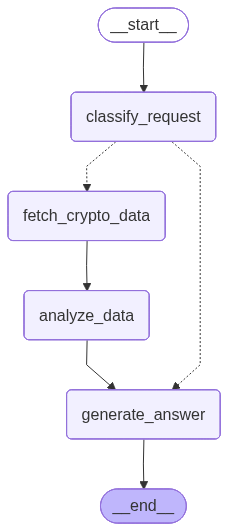

In [ ]:
builder = StateGraph(CryptoState)

builder.add_node("classify_request", classify_request)
builder.add_node("fetch_crypto_data", fetch_crypto_data)
builder.add_node("analyze_data", analyze_data)
builder.add_node("generate_answer", generate_answer)

builder.add_edge(START, "classify_request")

builder.add_conditional_edges(
    "classify_request",
    route_after_classification,
    {
        "fetch_crypto_data": "fetch_crypto_data",
        "generate_answer": "generate_answer",
    },
)

builder.add_edge("fetch_crypto_data", "analyze_data")
builder.add_edge("analyze_data", "generate_answer")
builder.add_edge("generate_answer", END)

graph = builder.compile()
graph

In [ ]:
def ask(question: str) -> str:
    initial = {
        "question": question,
        "question_kind": 0,
        "coin_id": "",
        "currency": "",
        "days": 0,
        "historical_data": None,
        "analysis_result": None,
        "answer": ""
    }
    return graph.invoke(initial)["answer"]

In [ ]:
print(ask("Как изменился биткоин за неделю?"))

classify_request raw: {
  "question_kind": 2,
  "coin_id": "bitcoin",
  "currency": "usd",
  "days": 7
}
Fetching data for bitcoin, usd, last 7 days
Bitcoin за последние 7 дней (USD):
- Начальная цена: 69831.65 USD
- Конечная цена: 70313.79 USD
- Изменение: 0.69%
- Максимум: 75632.41 USD
- Минимум: 69298.88 USD
- Волатильность: 9.07%


In [ ]:
print(ask("Сколько сейчас стоит биткоин?"))

classify_request raw: {
  "question_kind": 1,
  "coin_id": "bitcoin",
  "currency": "usd",
  "days": 7
}
Fetching data for bitcoin, usd, last 7 days
Сейчас Bitcoin в среднем стоит около 70476.28 USD.
Последнее значение из API: 70476.28 USD.


In [ ]:
print(ask("Сколько лет Льву Толстому?"))

classify_request raw: ```json
{
  "question_kind": 0,
  "coin_id": "invalid",
  "currency": "usd",
  "days": 7
}
```
ОШИБКА: задайте корректный запрос про Bitcoin


##Часть 2

**Дешифруем каракули Марка**

In [ ]:
!pip install -U bitsandbytes>=0.46.1

In [ ]:
!pip install Pillow==10.4.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 96.0 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import re
import zipfile
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance, ImageStat
from tqdm.auto import tqdm
import torch
from transformers import AutoProcessor, BitsAndBytesConfig, Qwen2_5_VLForConditionalGeneration


extract_dir = "/content/drive/MyDrive/Colab Notebooks/pictures_iad (1)"
IMG_EXTS = {".jpg"}

image_paths = [
    os.path.join(extract_dir, f)
    for f in os.listdir(extract_dir)
    if os.path.splitext(f)[1].lower() in IMG_EXTS and os.path.isfile(os.path.join(extract_dir, f))
]

image_paths = sorted(image_paths)
print("Всего картинок:", len(image_paths))
print("Файлы:", [os.path.basename(p) for p in image_paths])

Всего картинок: 6
Файлы: ['IMG_2694.jpg', 'IMG_2695.jpg', 'IMG_2696.jpg', 'IMG_2697.jpg', 'IMG_99998.jpg', 'IMG_99999.jpg']


In [ ]:
def prepare_image(path):
    img = Image.open(path).convert("RGB")
    gray = img.convert("L")
    stat = ImageStat.Stat(gray)
    mean_brightness = stat.mean[0] / 255
    w, h = img.size
    max_side = max(w, h)

    if mean_brightness > 0.75:
        img = ImageEnhance.Contrast(img).enhance(1.8)
    elif mean_brightness < 0.35:
        img = ImageOps.autocontrast(img)

    if max_side > 1600:
        scale = 1600 / max_side
        new_size = (max(1, int(w * scale)), max(1, int(h * scale)))
        img = img.resize(new_size, Image.Resampling.LANCZOS)

    return img

In [ ]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

MODEL = "Qwen/Qwen2.5-VL-3B-Instruct"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL,
    device_map="auto",
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
)

processor = AutoProcessor.from_pretrained(MODEL)

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
            (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear4bit(in_features=3420, out_features=1280, bias=True)
        

In [ ]:
PROMPT = (
    "You are an OCR engine specialized in handwritten Russian text. Transcribe the handwritten text exactly as it appears in the image. "
    "Preserve original line breaks, punctuation, capitalization, and spelling. "
    "Focus on producing a precise, faithful transcription of the handwritten input."
    "Output only the transcription, with no explanation."
)

In [ ]:
@torch.no_grad()
def predict_one(image_path: str) -> str:
    image = prepare_image(image_path)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": PROMPT},
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )

    inputs = inputs.to(model.device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    output = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

    return output

In [ ]:
hyps = []
files = []

for img_path in tqdm(image_paths):
    pred = predict_one(img_path)
    hyps.append(pred)
    files.append(os.path.basename(img_path))

  0%|          | 0/6 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [ ]:
out_csv = "/content/predictions.csv"
pd.DataFrame({
    "file_name": files,
    "prediction": hyps
}).to_csv(out_csv, index=False, encoding="utf-8")
print("Предсказания:")
for i in range(len(hyps)):
    print("----")
    print(files[i])
    print(hyps[i])

Предсказания:
----
IMG_2694.jpg
С современные языки программирования, такие как Python, Java и C++, подвижном
нашагать широкий спектр задач - от создания веб-сайтов до разработки
мощных систем искусственного интеллекта. Каждый язык обладает
своей философией и областью применения, но все они охватывают на
разных уровнях: алгоритмы, структуры данных и т.д.
----
IMG_2695.jpg
Программирование – это не просто механический навык, а особый способ мышления, позволяющий человеку создавать новые цифровые миры. В XXI веке оно стало универсальным языком взаимодействия с технологиями. Подобно тому как когда-то знание грамоты открывало доступ к культуре и науке, сегодня умение писать код открывает путь к исследованиям, автоматизации и творчеству.
----
IMG_2696.jpg
История пропагандирования математики и алгоритмов в науке проходит в ряде случаев с начала XIX века. Начало первых научных исследований в области алгоритмов и математических методов приходится на 1820-е годы. С развитием математического об

In [ ]:
!pip install cer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 83.5 MB/s eta 0:00:00


In [ ]:
from cer import calculate_cer_corpus


refs = ["""Современные языки программирования, такие как Python, Java и C++, позволяют решать широкий спектр задач — от создания веб-сайтов до разработки сложных систем искусственного интеллекта. Каждый язык обладает своей философией и областью применения, но все они основаны на общих принципах: алгоритмах, структурах данных и логике.""",
"""Программирование — это не просто технический навык, а особый способ мышления, позволяющий человеку создавать новые цифровые миры. В XXI веке оно стало универсальным языком взаимодействия с технологиями. Подобно тому как когда-то знание грамоты открывало доступ к культуре и науке, сегодня умение писать код открывает путь к инновациям, автоматизации и творчеству.""",
"""История программирования начинается задолго до появления современных компьютеров. Идеи алгоритмов можно проследить ещё в работах математиков прошлого, а в XIX веке Ада Лавлейс создала описание алгоритма для аналитической машины, став первым в мире программистом. С развитием вычислительной техники программирование превратилось в самостоятельную область знаний, объединяющую математику, инженерию и логику.""",
"""Это первая домашка на ИАДе.
Она, кажется, простая, но пока никто её не решил...""",
"""Сытость совсем не зависит от того,
сколько мы едим, а от того, как мы едим!
Так и счастье, так и счастье, Лёвушка,
оно вовсе не зависит от объёма
внешних благ, которые мы урвали у
жизни. Оно зависит только от нашего
отношения к ним! Об этом сказано ещё в
даосской этике: «Кто умеет
довольствоваться, тот всегда будет
доволен.""",
"При наличии уважительной причины дедлайн по д/з может быть перенесён. Дедлайн по д/з переносится на кол-во дней, равное продолжительности ув. причины."]

hyps = [sent.split() for sent in hyps]
refs = [sent.split() for sent in refs]

cer_corpus_score = calculate_cer_corpus(hyps, refs)
cer_corpus_score

{'count': 6,
 'mean': 0.20322223689575028,
 'median': 0.11054033485540335,
 'std': 0.2799297126885607,
 'min': 0.012658227848101266,
 'max': 0.7552742616033755,
 'cer_scores': [0.1388888888888889,
  0.02452316076294278,
  0.7552742616033755,
  0.012658227848101266,
  0.20579710144927535,
  0.0821917808219178]}

In [ ]:
print(3 * min(1, 1 - cer_corpus_score["mean"] + 0.19))

2.960333289312749
